In [24]:
import numpy as np
import h5py
import torch
from score_models import NCSNpp
import torch.nn.functional as F
import os, re, json
from scope.definitions import DEVICE
from glob import glob
from astropy.io import fits
from functorch import vjp, vmap
from tqdm import tqdm
import matplotlib.pyplot as plt

In [25]:
def load_model(checkpoint_dir, architecture=NCSNpp):
    model_name = os.path.split(checkpoint_dir)[-1]
    with open(os.path.join(checkpoint_dir, "model_hparams.json"), "r") as f:
        hyperparameters = json.load(f)
    model = architecture(**hyperparameters).to(DEVICE)
    paths = glob(os.path.join(checkpoint_dir, "checkpoint*.pt"))
    checkpoints = [int(re.findall('[0-9]+', os.path.split(path)[-1])[-1]) for path in paths]
    model.eval()
    for p in model.parameters(): p.requires_grad = False  # being extra careful for some reasons
    model.load_state_dict(torch.load(paths[np.argmax(checkpoints)], map_location=DEVICE))
    print(f"Loaded checkpoint {max(checkpoints)} of {model_name}")
    return model

In [26]:
skirt_data_path = "/home/aadam/scratch/skirt512_grizy.h5"
probes_data_path = "/home/aadam/projects/rrg-lplevass/probes.h5"

slic_checkpoint_dir = "/home/aadam/scratch/DeblendingGalaxies/models/ncsnpp_hst_noise_psf_f814w_wfc3uv_230421041030"
skirt_prior_checkpoint_dir = "/home/aadam/scratch/DeblendingGalaxies/models/ncsnpp_skirt_g_230415205127"
probes_prior_checkpoint_dir = "/home/aadam/projects/rrg-lplevass/data/score_models/ncsnpp_ct_g_220912024942"

In [27]:
slic_model = load_model(slic_checkpoint_dir)
prior_model = load_model(skirt_prior_checkpoint_dir)
prior_model = load_model(probes_prior_checkpoint_dir)

Loaded checkpoint 139 of ncsnpp_hst_noise_psf_f814w_wfc3uv_230421041030
Loaded checkpoint 30 of ncsnpp_skirt_g_230415205127
Loaded checkpoint 554 of ncsnpp_ct_g_220912024942


In [28]:
def interpolate(image, coordinates):
    """
    Interpolation function, without a batch size. To make it batched, used vmap from functorch.
    """
    C, H, W = image.shape
    x, y = torch.tensor_split(coordinates, 2, dim=0)
    x = x.view(-1)
    y = y.view(-1)
    x0 = torch.floor(x).long()
    x1 = x0 + 1
    y0 = torch.floor(y).long()
    y1 = y0 + 1

    x0 = torch.clip(x0, 0, W - 1)
    x1 = torch.clip(x1, 0, W - 1)
    y0 = torch.clip(y0, 0, H - 1)
    y1 = torch.clip(y1, 0, H - 1)
    x = torch.clip(x, 0, W - 1)
    y = torch.clip(y, 0, H - 1)

    Ia = image[..., x0, y0]
    Ib = image[..., x0, y1]
    Ic = image[..., x1, y0]
    Id = image[..., x1, y1]

    wa = (x1 - x) * (y1 - y)
    wb = (x1 - x) * (y - y0)
    wc = (x - x0) * (y1 - y)
    wd = (x - x0) * (y - y0)

    _, new_H, new_W = coordinates.shape
    return (wa * Ia + wb * Ib + wc * Ic + wd * Id).view(C, new_H, new_W)

In [29]:
psf_file = "/home/aadam/scratch/DeblendingGalaxies/data/F814w_WFC3UV_cropped_psf.fits"
with fits.open(psf_file) as data:
    psf = data["PRIMARY"].data[None].astype(np.float32) # add the channel dimension, a single channel for now.

In [30]:
sigma_min = prior_model.sde.sigma_min
sigma_max = prior_model.sde.sigma_max

def sigma(t): # scale of the marginal prob. distiribution
    return sigma_min * (sigma_max / sigma_min)**t.view(-1, 1, 1, 1)
def g(t): # diffusion coefficient of the VESDE
    return sigma(t) * np.sqrt(2 * (np.log(sigma_max) - np.log(sigma_min)))

In [31]:
def preprocess_probes_g_channel(img):  # channel 0
    img = torch.clamp(img, 0, 1.48)
    img = 2 * img / 1.48 - 1.
    return img


In [39]:
def link_function(x):
    return (x + 1) / 2.

with h5py.File("/home/aadam/projects/rrg-lplevass/data/probes.h5") as hf:
    source = hf["galaxies"][101, ..., 0]
source = preprocess_probes_g_channel(torch.tensor(source).to(DEVICE).view(1, 1, *source.shape))

In [40]:
# from PIL import Image
# import torchvision.transforms as T

# transform = T.Compose([
#             T.Resize(256),
#             T.Grayscale()
#         ])
# path = "/home/aadam/scratch/GravScope/data/DALL·E 2022-09-19 12.00.55 - A galaxy in the shape of the number 7 on a dark background.png"
# image = Image.open(path)
# image = image.convert('RGB')  # remove the alpha channel when it is present
# image = T.ToTensor()(image)
# C, H, W = image.shape
# if H != W:
#     if H < W:
#         h1 = (W - H) // 2
#         h2 = (W - H) // 2 + h1 % 2
#         w1 = 0
#         w2 = 0
#     else:
#         h1 = 0
#         h2 = 0
#         w1 = (H - W) // 2
#         w2 = (H - W) // 2 + w1 % 2
#     image = T.Pad(padding=(w1, h1, w2, h2))(image)
# source = transform(image).to(DEVICE).view(1, 1, 256, 256) * 2 - 1

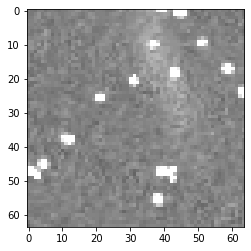

In [41]:
from torchvision.transforms import CenterCrop


path = "/home/aadam/projects/rrg-lplevass/data/hst_cutouts_noclip.npy"
# path = "/home/aadam/projects/rrg-lplevass/data/hst_inference_noise.npy"

noise_map = np.load(path)[25].astype(np.float32) # 9 is good for the galaxy
noise_map = CenterCrop(64)(torch.tensor(noise_map).to(DEVICE).view(1, 1, *noise_map.shape))
plt.imshow(noise_map.squeeze().cpu(), cmap="gray", vmin=-0.04, vmax=0.08)

In [42]:
observation_pixels = 64
observation_pixel_size = 0.04
super_sampling_factor = 4
model_pixel_size = 0.01
model_pixels = 256
zero_padding = 0

def make_forward_model(psf):
    C, H, W = psf.shape
    psf = torch.tensor(psf).to(DEVICE).view(C, 1, H, W) # reshape to a convolution kernel [channel_out, channels_in/groups, H, W]
    batched_interpolation = vmap(interpolate, in_dims=(0, None))  # only batch over the images

    # TODO support a shift of the ccordinates
    # define target coordinates at the super sampling resolution of the psf

    
    fov = observation_pixel_size * observation_pixels
    x = torch.linspace(-1, 1, super_sampling_factor*observation_pixels).float() * fov / 2
    x, y = torch.meshgrid(x, x, indexing="ij")  # TODO make this coherent with WCS
    # Transform these coordinates into model pixel indices
    _min = - model_pixel_size * (model_pixels + zero_padding) / 2
    i_coord = (x - _min) / model_pixel_size
    j_coord = (y - _min) / model_pixel_size
    coordinates = torch.stack([i_coord, j_coord], dim=0).to(DEVICE)
    def A(x):
        x = F.pad(x, pad=[zero_padding]*4, mode="constant", value=0.)
        x = batched_interpolation(x, coordinates)
        x = F.conv2d(x, psf, groups=C, padding="same")
        x = F.avg_pool2d(x, kernel_size=super_sampling_factor, stride=super_sampling_factor)
        return x
    return A


In [43]:
%%timeit
# test input output shape of slic model vjp strategy
observation = torch.randn(5, 1, observation_pixels, observation_pixels).to(DEVICE)
x = torch.randn(5, 1, model_pixels, model_pixels).to(DEVICE)
t = torch.rand(5).to(DEVICE)
def convolved_likelihood_gradient(x, t):
    y_hat, vjpfunc = vjp(forward_model, x)
    score = slic_model.score(observation - y_hat, t)
    grad = vjpfunc(score)[0]
    return -grad
# convolved_likelihood_gradient = vmap(convolved_likelihood_gradient_fn)
# print(convolved_likelihood_gradient(x, t).shape)

del x
del t
del observation

2.94 ms ± 9.01 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


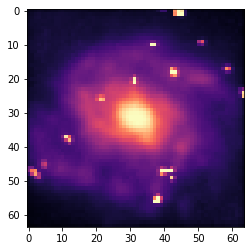

In [44]:
forward_model = make_forward_model(psf)
observation = forward_model(link_function(source)) + noise_map

plt.imshow(observation.squeeze().cpu(), cmap="magma", vmax=1)

# Test sampling from SLIC model: requires sending brownian motion to the observation space

In [ ]:
observation_pixels = 128
observation_pixel_size = 0.04
super_sampling_factor = 4
model_pixel_size = 0.01
model_pixels = 512
zero_padding = 0

def make_forward_model(psf):
    C, H, W = psf.shape
    psf = torch.tensor(psf).to(DEVICE).view(C, 1, H, W) # reshape to a convolution kernel [channel_out, channels_in/groups, H, W]
    batched_interpolation = vmap(interpolate, in_dims=(0, None))  # only batch over the images

    # TODO support a shift of the ccordinates
    # define target coordinates at the super sampling resolution of the psf

    
    fov = observation_pixel_size * observation_pixels
    x = torch.linspace(-1, 1, super_sampling_factor*observation_pixels).float() * fov / 2
    x, y = torch.meshgrid(x, x, indexing="ij")  # TODO make this coherent with WCS
    # Transform these coordinates into model pixel indices
    _min = - model_pixel_size * (model_pixels + zero_padding) / 2
    i_coord = (x - _min) / model_pixel_size
    j_coord = (y - _min) / model_pixel_size
    coordinates = torch.stack([i_coord, j_coord], dim=0).to(DEVICE)
    def A(x):
        x = F.pad(x, pad=[zero_padding]*4, mode="constant", value=0.)
        x = batched_interpolation(x, coordinates)
        x = F.conv2d(x, psf, groups=C, padding="same")
        x = F.avg_pool2d(x, kernel_size=super_sampling_factor, stride=super_sampling_factor)
        return x
    return A


In [10]:
N = 1000

def slic_euler_maruyama_step(y, t, dt):
    B = y.shape[0]
    t += dt
    y_mean = y - g(t) ** 2 * slic_model.score(y, t) * dt
    z = forward_model(torch.randn(B, 1, model_pixels, model_pixels).to(DEVICE))
    y = y_mean + g(t) * z * np.sqrt(-dt)
    return y_mean, y, t

B = 6
noise_samples = []
with torch.no_grad():
    dt = -1. / N
    t = torch.ones(B).to(DEVICE)
    y = forward_model(torch.randn(B, 1, model_pixels, model_pixels).to(DEVICE)) * sigma(t) # TODO add channels
    for _ in tqdm(range(N)):
        y_mean, y, t = slic_euler_maruyama_step(y, t, dt)
        noise_samples.append(y.cpu().numpy().squeeze())
noise_samples = np.stack(noise_samples)
np.save("../data/noise_samples.npy", noise_samples)

100%|██████████| 1000/1000 [03:29<00:00,  4.77it/s]


AttributeError: module 'matplotlib.pyplot' has no attribute 'save'

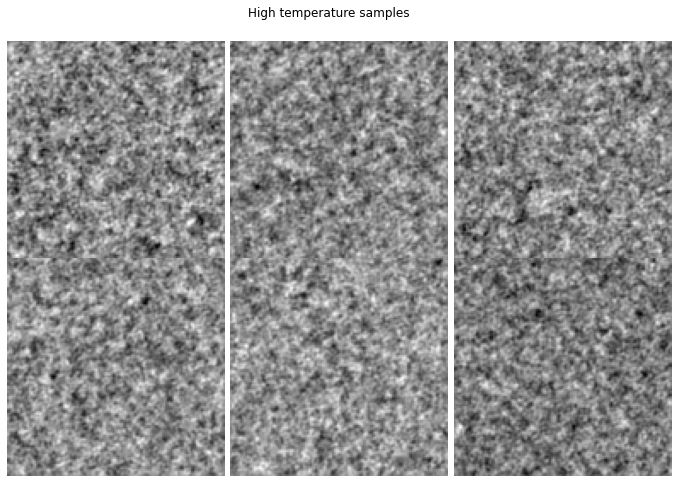

In [12]:
t = torch.ones(B).to(DEVICE)
high_temperature_y = forward_model(torch.randn(B, 1, model_pixels, model_pixels).to(DEVICE)) * sigma(t) # TODO add channels
fig, axs = plt.subplots(2, 3, figsize=(12, 8))
for i in range(2):
    for j in range(3):
        k = i * 3 + j
        axs[i, j].imshow(high_temperature_y[k].cpu().squeeze(), cmap="gray")
        axs[i, j].axis("off")
fig.suptitle("High temperature samples", y=0.94)
plt.subplots_adjust(hspace=0, wspace=0)

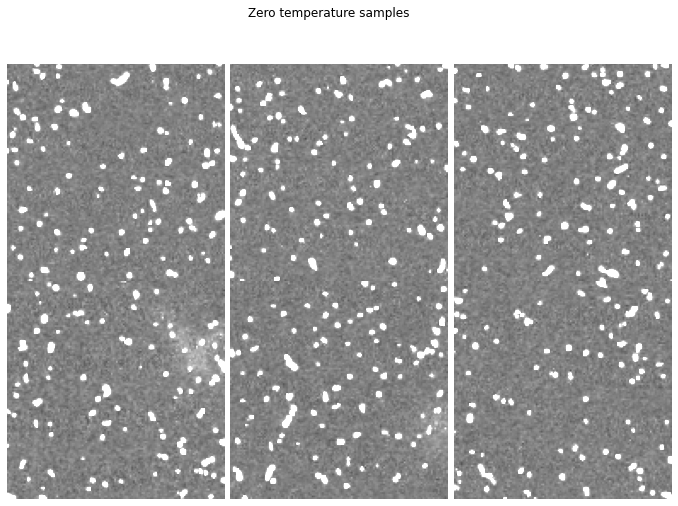

In [13]:
fig, axs = plt.subplots(2, 3, figsize=(12, 8))
for i in range(2):
    for j in range(3):
        k = i * 3 + j
        axs[i, j].imshow(y[k].cpu().squeeze(), cmap="gray", vmin=-0.04, vmax=0.08)
        axs[i, j].axis("off")
fig.suptitle("Zero temperature samples")
plt.subplots_adjust(hspace=0, wspace=0)

# Now test inference with our noise map

In [14]:
# HST WFC3 UVIS F814W
photflam = 1.4980e-19	
photplam = 8039.1 # angstrom
minimum_count = 0.
LOG10 = np.log(10.)

def ab_mag_to_jansky_per_arcsec_squared(img):
    return 10**(-(img - 8.9) / 2.5)

def electron_count_to_ab_mag(img):
    """
    Assumes img is a torch tensor, expressed in electron / sec units.

    photflam and photplam are usually found in HST fits file headers, and refer to the
    inverse sensitivity (in erg/cm^2/sec/Angstrom) and the pivot wavelength respectively.
    See https://hst-docs.stsci.edu/acsdhb/chapter-5-acs-data-analysis/5-1-photometry.

    """
    zero_point = -2.5* np.log10(photflam) - 21.10 - 5 * np.log10(photplam) + 18.6921
    return -2.5 * torch.log(torch.maximum(torch.ones_like(img) * minimum_count, img)) / LOG10 + zero_point

def ab_mag_to_jansky_per_arcsec_squared(img):
    return 10**(-(img - 8.9) / 2.5)

def hst_observation_preprocessing(img):
    img = electron_count_to_ab_mag(img)
    img = 1e6 * ab_mag_to_jansky_per_arcsec_squared(img) # convert to micro Jansky / arcsec^2
    return img

def preprocessing(img, dynamic_range=1e5):
    img = ab_mag_to_jansky_per_arcsec_squared(img)
    return torch.log(1e6 * img + 1/dynamic_range) / np.log(10.) + np.log10(dynamic_range)

def inverse_preprocessing(img, dynamic_range=1e5):
    return 10**(img - np.log10(dynamic_range))

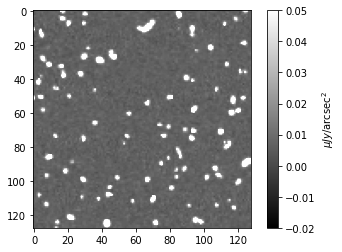

In [15]:
noise = y[0]
plt.imshow(hst_observation_preprocessing(noise).cpu().squeeze(), cmap="gray", vmin=-0.02, vmax=0.05)
plt.colorbar(label=r"$\mu Jy / \mathrm{arcsec}^2$")

Text(0.5, 1.0, 'HST like observation')

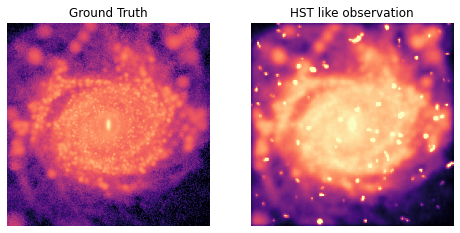

In [24]:
# Pick a reference GT
index = 42
with h5py.File(skirt_data_path, "r") as hf:
    ground_truth = torch.tensor(hf["images"][index, ..., 0]).view(1, 1, 512, 512).to(DEVICE)
ground_truth = preprocessing(ground_truth) 
# ground_truth = inverse_preprocessing(ground_truth)
observation = forward_model(ground_truth) + 5*noise
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(ground_truth.cpu().squeeze(), cmap="magma")
axs[1].imshow((observation).cpu().squeeze(), cmap="magma", vmax=5)
axs[0].axis("off")
axs[1].axis("off")
axs[0].set_title("Ground Truth")
axs[1].set_title("HST like observation")

# The reverse time SDE with non-linear preprocessing
Since we must introduce a preprocessing step $\mathbf{x}_t = \Psi(\boldsymbol{\xi})$, where $\boldsymbol{\xi}_t$ are samples from the prior at temperature $t$, we must modify the SDE to account for this. To do this, we use Itô's lemma to relate the $\mathbf{x}$ to $\boldsymbol{\xi}$. First, we recall our VESDE for the prior random variable
$$
    d\boldsymbol{\xi} = g(t) d \mathbf{w}
$$
By Itô's lemma, we then have
$$
    d\mathbf{x} = \frac{1}{2}g^2(t) \mathrm{Tr}(\mathbf{H}_\boldsymbol{\xi} \Psi)dt + g(t) \nabla_\boldsymbol{\xi} \Psi^T d\mathbf{w}
$$
where $\mathbf{H}_\boldsymbol{\xi}$ is the Hessian of the transform and $ \nabla_\boldsymbol{\xi} \Psi$ is the Jacobian matrix. 
As we can see, we must carry an extra drift and project the diffusion term with the Jacobian of the transformation. Luckily, since our transformation is pixel-wise, the Jacobian matrix is diagonal. 

Our transformation is 
$$
    \psi(\boldsymbol{\xi}) = 10^{\boldsymbol{\xi} - C}
$$
where $C$ is a normalisation constant. Thus
$$
    \nabla_{\boldsymbol{\xi}_i} \Psi = \log(10) 10^{\boldsymbol{\xi_j} - C} \delta_{ij}
$$
And
$$
\begin{align}
    \mathrm{Tr}(\mathbf{H}_\boldsymbol{\xi} \Psi) 
    &= \sum_{i=1}^D \nabla_{\boldsymbol{\xi}_i} \nabla_{\boldsymbol{\xi}_i} \Psi  \\
    &= \log(10)\sum_{i=1}^D \nabla_{\boldsymbol{\xi}_i}  10^{\boldsymbol{\xi}_j - C} \delta_{ij} \\
    &= \log(10)^2 \sum_{i=1}^D  10^{\boldsymbol{\xi}_j - C}\delta_{ij}\\
    &= \log(10)^2  10^{\boldsymbol{\xi} - C}
 \end{align}
$$

Note that the Kronecker delta in the Jacobian means that the diffusion term can be written as the Hadamard product between the diagonal vector of the Jacobian and the Brownian motion term. Thus, we can finally write
$$
    d\mathbf{x} = \frac{1}{2}g^2(t) \log(10)^2 \mathbf{x}dt +  g(t)  \log(10) \mathbf{x} \circ d\mathbf{w}
$$
where $\circ$ denoted the Hadamard product, not the Stratonovich interpretation of the diffusion term. This is a bit messy, so we might want to use a different notation.

We also want to rescale the prior variable to avoid the explosion in the exponential. So we choose a scaled R.V. related to $\boldsymbol{\xi}$ by
$$
    \boldsymbol{\xi}' = \beta(t) \boldsymbol{\xi}
$$
where $\beta(t)$ is a particular schedule that converges to 1 once the temperature reaches an acceptable level, say $\sigma(t) = 1$, after which we make the schedule unity. 
$$
    \beta(t) = \min\left(1, \frac{1}{\sigma(t)}\right)
$$
Ignoring for a moment the fact the the schedule cannot be diferentiated at $t^*$ s.t. $\sigma(t^*) = 1$, we can evaluate its derivative
$$
    \dot{\beta}(t) = 
    \begin{cases}
        0 & t < t^*\\
        -\frac{1}{\sigma(t)^2} & t > t^*
    \end{cases}
$$

Rescaling the R.V. has the effect of adding yet another drift term in our equation. Indeed, we have that
$$
\begin{align}
    \frac{\partial \Psi}{\partial t} 
            &= \frac{\partial }{\partial t} 10^{\beta(t) \xi - C} \\
            &= \log(10)\dot{\beta}(t) 10^{\beta(t) \xi - C} \\
            &= \log(10)\dot{\beta}(t) \mathbf{x} \\
\end{align}
$$
Thus, our final expression for the forward time SDE is, using Itô's lemma,
$$
       d\mathbf{x} = \left(\log(10)\dot{\beta(t)} \mathbf{x} + \frac{1}{2}g^2(t) \log(10)^2 \mathbf{x} \right)dt + g(t)  \log(10) \mathbf{x} \circ d\mathbf{w}
$$

We are finally in a position to use Anderson's reverse-time formula, which states that for $\mathbf{x}_T \sim \pi(\mathbf{x})$ and $dt < 0$, we can write
$$
    d \mathbf{x} = \left(\log(10)\dot{\beta(t)}\mathbf{x} + \frac{1}{2}g^2(t) \log(10)^2 \mathbf{x} - g^2(t)\nabla_{\mathbf{x}'}\log p_t(\mathbf{x}) \right)dt + g(t)  \log(10) \mathbf{x} \circ d\mathbf{w}
$$
where $p_t(\mathbf{x})$ is the marginal distribution at time $t$ that solve the Fokker-Planck equation associated with our forward SDE. Now, we first assume that we can write this expression in term of the posterior without changing the high temperature boundary condition. Then, applying Baye's theorem, we find
$$
    d \mathbf{x} = \left(\log(10)\dot{\beta}(t) \mathbf{x}  + \frac{1}{2}g^2(t) \log(10)^2 \mathbf{x} - g^2(t)(\nabla_{\mathbf{x}}\log p_t(\mathbf{y} \mid \mathbf{x}) + \nabla_{\mathbf{x}}\log p_t(\mathbf{x})) \right)dt + g(t)  \log(10) \mathbf{x} \circ d\mathbf{w}
$$

Now, we are diffusing in a space that is more numerically stable for our forward model. We must yet do another step to take into account the space in which our neural network operate. In practice, the SLIC likelihood must be trained with noise that is preprocess so that the gradient here is well defined. 
#TODO inclue preprocessing in SLIC training

Since the prior is defined in terms of $\xi$, we write
$$
\begin{align}
\nabla_{\mathbf{x}}\log p_t(\mathbf{x}) &= \nabla_{\boldsymbol{\xi}}\log p_t(\Psi^{-1}(\mathbf{x})) \frac{\partial \Psi^{-1}}{\partial \mathbf{x}} \\
\end{align}
$$
Since 
$$
    \Psi^{-1}(\mathbf{x}) = \log_{10}(\mathbf{x}) + C
$$
We have
$$
    \frac{\partial \Psi^{-1}}{\partial \mathbf{x}} = \frac{1}{\log(10)} \frac{1}{\mathbf{x}}
$$


## Could we make a different choice for the SDE?

Let's write our SDE, but now diffusing in the prior space. In this case, the SDE should much simpler to write, but a Jacobian matrix will appear in front of the likelihood score in the reverse time SDE
$$
    d \boldsymbol{\xi} = - g^2(t)(\nabla_{\boldsymbol{\xi}} \log p_t(\boldsymbol{\xi}) + \nabla_{\boldsymbol{\xi}} \log p(\mathbf{y} \mid \boldsymbol{\xi})) dt + g(t) d \mathbf{w}
$$

Since the likelihood is defined in term of $\mathbf{x}$, we must write
$$
       d \boldsymbol{\xi} = - g^2(t)\left(\nabla_{\boldsymbol{\xi}} \log p_t(\boldsymbol{\xi}) + \nabla_{\mathbf{x}} \log p(\mathbf{y} \mid \Psi(\boldsymbol{\xi})) \frac{\partial \Psi(\boldsymbol{\xi})}{ \partial \boldsymbol{\xi}}\right) dt + g(t) d \mathbf{w}
$$
where
$$
    \frac{\partial \Psi(\boldsymbol{\xi})}{ \partial \boldsymbol{\xi}} = \log(10) 10^{\boldsymbol{\xi} - C}
$$
Again, introduing our scaling schedule $\beta(t)$, with $\boldsymbol{\xi}' = \beta(t) \boldsymbol{\xi}$, we have, using Itô's lemma and the chain rule, 
$$
     d \boldsymbol{\xi}' = \dot{\beta}(t) \boldsymbol{\xi} dt - \beta(t) g^2(t)\left(\nabla_{\boldsymbol{\xi}} \log p_t(\boldsymbol{\xi}) + \nabla_{\mathbf{x}} \log p(\mathbf{y} \mid \Psi(\boldsymbol{\xi})) \frac{\partial \Psi(\boldsymbol{\xi})}{ \partial \boldsymbol{\xi}}\right) dt + \beta(t) g(t) d \mathbf{w}
$$

## Can we actually use SLIC with that SDE?

To use SLIC, we remember tha the inverse problem can be written as
$$
    \mathbf{y} = A (\mathbf{x} + \mathbf{z}_t) + \mathbf{z}_y
$$
where $\mathbf{z}_y$ is a vector of irreducible noise in the observation and $\mathbf{z}_t$ is an added temperature form our model. Under the assumption that the forward model is linear ($A$ matrix), then we can write
$$
    \mathbf{y} - A \mathbf{x} =  A\mathbf{z}_t + \mathbf{z}_y \sim p_y(\mathbf{z}_y) \circledast \mathcal{N}(A\mathbf{z}_t \mid 0, AA^T \sigma(t)^2)
$$
The covariance matrix follows from projecting normal noise $\mathbf{z}_t\mathcal{N}(0, \sigma^2(t)\mathbb{1})$ onto a space with the projection operator $A$. In the end, we can write
$$
    \nabla_{\mathbf{x}} \log p(\mathbf{y} \mid \mathbf{x}) = -\nabla_{\mathbf{y} - A \mathbf{x}} \log Q(\mathbf{y} - A \mathbf{x}) A
$$

Since the preprocessing operation is non-linear, it is difficult to separate it from the model parameters $\mathbf{x}$ as we just did. Thus we cannot use our SLIC training strategy based on the previous observation. However, let us suppose that the link function is separable in the following way
$$
    \Psi(\mathbf{x} + \mathbf{z}) = \Psi(\mathbf{x})\Psi(\mathbf{z})
$$
This is definitively the case for our non-linear preprocessing. Thus, we can make the following observation
$$
\begin{align}
    \mathbf{y} &= A \Psi(\mathbf{x} + \mathbf{z}_t) + \mathbf{z}_y\\
              &=  A(\Psi(\mathbf{x}) \Psi(\mathbf{z}_t)) + \mathbf{z}_y\\
   \implies \log(\mathbf{y} - \mathbf{z}_y) &= \log(A\Psi(\mathbf{x})) + \log(A \Psi(\mathbf{z_t}))\\
   \implies \log(\mathbf{y} - \mathbf{z}_y) - \log(A\Psi(\mathbf{x})) &= \log(A \Psi(\mathbf{z_t}))
\end{align}
$$
What does this expression tell us? It tells us that we should first solve the linear inverse problem to figure the quantity $A(\Psi(\mathbf{x}) \Psi(\mathbf{z}_t))$, then solve a second inverse problem to isolate $\mathbf{x}$. This is a bit tricky if we want to do diffusion, since we now have an inverse problem to solve for each iterations of EM.


# Conclusion of these investigations
- Preprocessing is a pain. But I have the liberty to first preprocess the noise and the observation, in which case my inverse problem is trully linear because there is no unit convertions happening during inference. This amounts to folding the complexity of preprocessing an observation and its noise inside the SLIC learned distribution of noise.

# First, let's test this scaled SDE with the prior score only to verify that it works

In [80]:
def convolved_likelihood_gradient(x, t):
    y_hat, vjpfunc = vjp(lambda x: forward_model(link_function(x)), x)
    score = slic_model.score(observation - y_hat, t)
    grad = vjpfunc(score)[0]
    return -grad


def link_function(x):
    return (x + 1) / 2.
# We diffuse in x space, so make sure to go back to xi space when going in score model
def score_fn(x, t):
    B, *D = x.shape
    prior_score = prior_model(x, t) / sigma(t).view(B, *[1]*len(D))
    likelihood_score = convolved_likelihood_gradient(x, t)
    return prior_score + 2000*likelihood_score


In [81]:
# Note that diffusion is written in term of xi, so we only put the Jacobian in the likelihood term. This is easier than diffusing in x after some thought.
def euler_maruyama_step(x, t, dt):
    t += dt
    x_mean = x - (g(t)**2 * score_fn(x, t)) * dt
    z = torch.randn_like(x)
    x = x_mean + g(t) * z * np.sqrt(-dt)
    return x_mean, x, t

In [82]:
B = 12
N = 2000
with torch.no_grad():
    dt = -1. / N
    t = torch.ones(B).to(DEVICE)
    x = torch.randn(B, 1, model_pixels, model_pixels).to(DEVICE) * sigma(t) # TODO add channels
    for _ in tqdm(range(N)):
        x_mean, x, t = euler_maruyama_step(x, t, dt)

100%|██████████| 2000/2000 [21:45<00:00,  1.53it/s]


In [ ]:
fig, axs = plt.subplots(2, 6, figsize=(24, 8))
y_hat = forward_model(x_mean)

axs[0, 0].imshow(ground_truth.cpu().squeeze(), cmap="magma")
axs[0, 0].axis("off")
axs[1, 0].imshow(observation.cpu().squeeze(), cmap="magma", vmax=5)
axs[1, 0].axis("off")
for j in range(5):
    axs[0, j+1].imshow(x_mean[j].cpu().squeeze(), cmap="magma")
    axs[0, j+1].axis("off")
    axs[1, j+1].imshow(y_hat[j].cpu().squeeze(), cmap="magma", vmax=5)
    axs[1, j+1].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)

In [23]:
np.save("../data/slic_samples.npy", x_mean.cpu().numpy().squeeze())
np.save("../data/slic_samples_yhat.npy", y_hat.cpu().numpy().squeeze())
np.save

# Probes test with link function

In [23]:
observation.min()

tensor(0.0305, device='cuda:0')

In [35]:
y_hat.min()

tensor(0.0125, device='cuda:0')

In [36]:
observation.min()

tensor(0.0305, device='cuda:0')

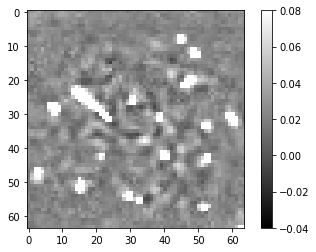

In [40]:
plt.imshow((observation - y_hat[j]).cpu().squeeze(), cmap="gray", vmin=-0.04, vmax=0.08)
plt.colorbar()

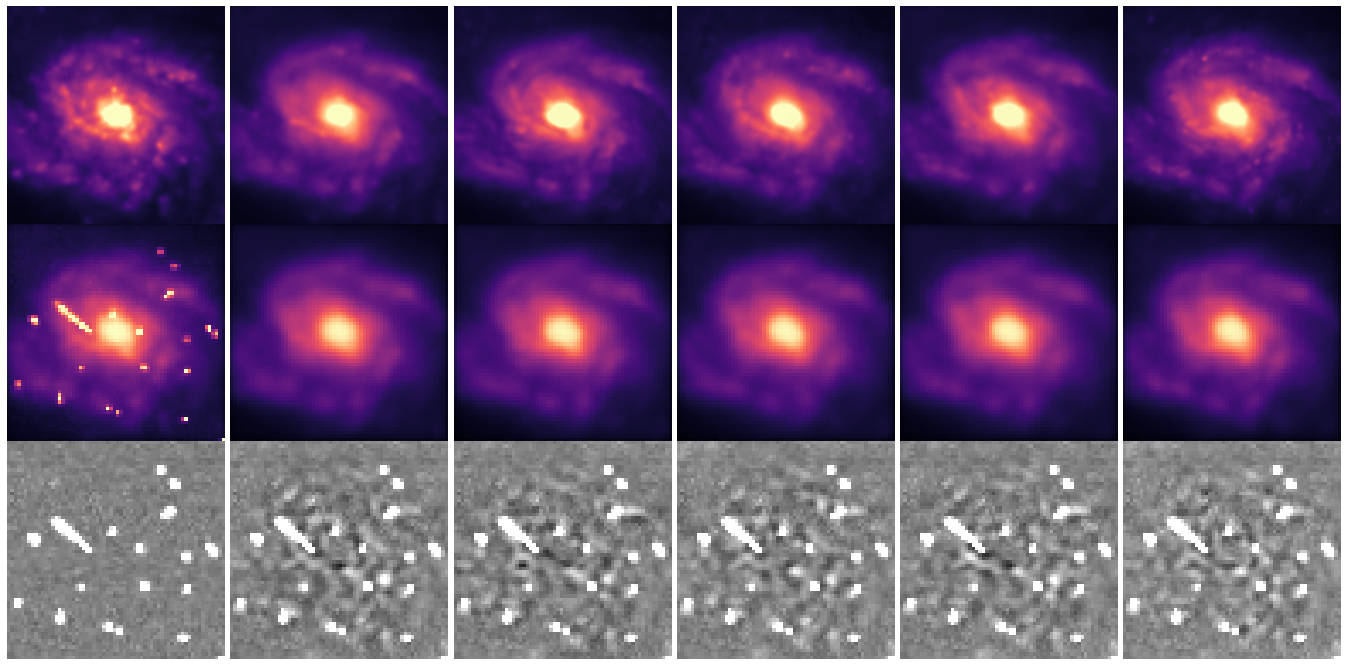

In [47]:
# fudge factor = 100
fig, axs = plt.subplots(3, 6, figsize=(24, 12))
y_hat = forward_model(link_function(x_mean))

axs[0, 0].imshow(link_function(source).cpu().squeeze(), cmap="magma", vmin=0, vmax=1)
axs[0, 0].axis("off")
axs[1, 0].imshow(observation.cpu().squeeze(), cmap="magma", vmin=0, vmax=1)
axs[1, 0].axis("off")
axs[2, 0].imshow(noise_map.cpu().squeeze(),  cmap="gray", vmin=-0.04, vmax=0.08)
axs[2, 0].axis("off")
for j in range(5):
    axs[0, j+1].imshow(link_function(x_mean[j]).cpu().squeeze(), cmap="magma", vmin=0, vmax=1)
    axs[0, j+1].axis("off")
    axs[1, j+1].imshow(y_hat[j].cpu().squeeze(), cmap="magma", vmin=0, vmax=1)
    axs[1, j+1].axis("off")
    axs[2, j+1].imshow((observation - y_hat[j]).cpu().squeeze(), cmap="gray", vmin=-0.04, vmax=0.08)
    axs[2, j+1].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)

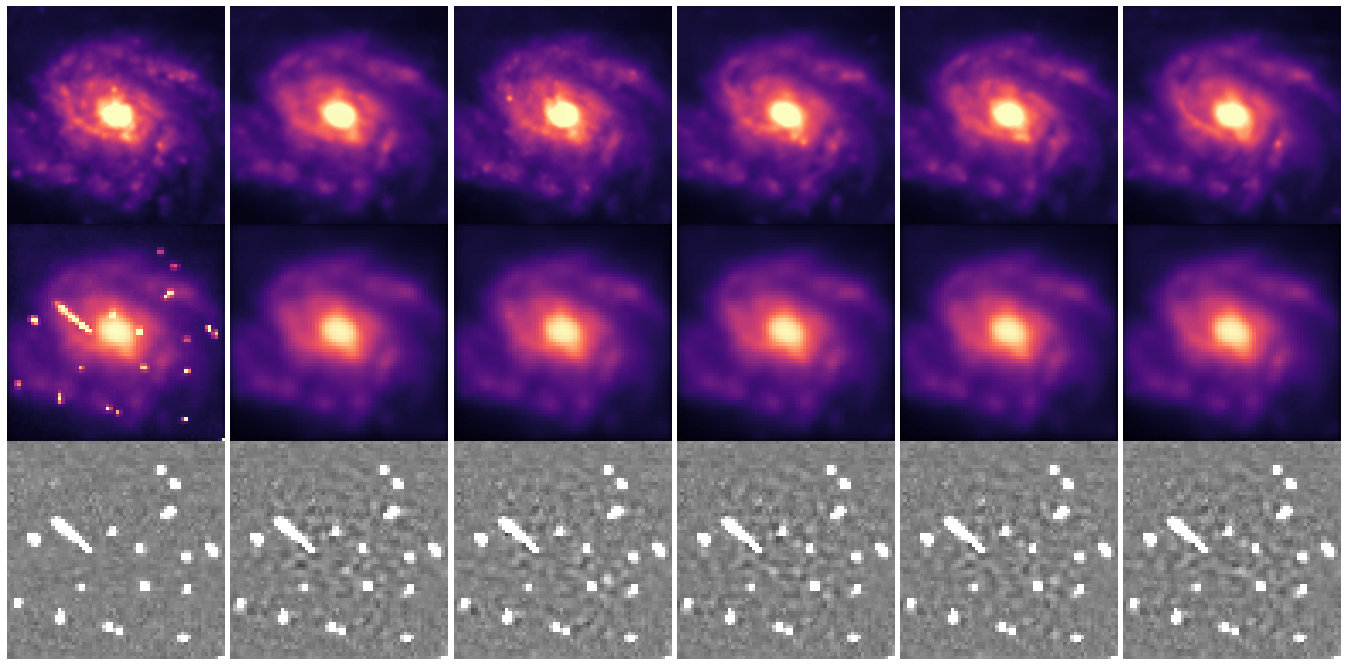

In [52]:
# fudge factor = 200
fig, axs = plt.subplots(3, 6, figsize=(24, 12))
y_hat = forward_model(link_function(x_mean))

axs[0, 0].imshow(link_function(source).cpu().squeeze(), cmap="magma", vmin=0, vmax=1)
axs[0, 0].axis("off")
axs[1, 0].imshow(observation.cpu().squeeze(), cmap="magma", vmin=0, vmax=1)
axs[1, 0].axis("off")
axs[2, 0].imshow(noise_map.cpu().squeeze(),  cmap="gray", vmin=-0.04, vmax=0.08)
axs[2, 0].axis("off")
for j in range(5):
    axs[0, j+1].imshow(link_function(x_mean[j]).cpu().squeeze(), cmap="magma", vmin=0, vmax=1)
    axs[0, j+1].axis("off")
    axs[1, j+1].imshow(y_hat[j].cpu().squeeze(), cmap="magma", vmin=0, vmax=1)
    axs[1, j+1].axis("off")
    axs[2, j+1].imshow((observation - y_hat[j]).cpu().squeeze(), cmap="gray", vmin=-0.04, vmax=0.08)
    axs[2, j+1].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)

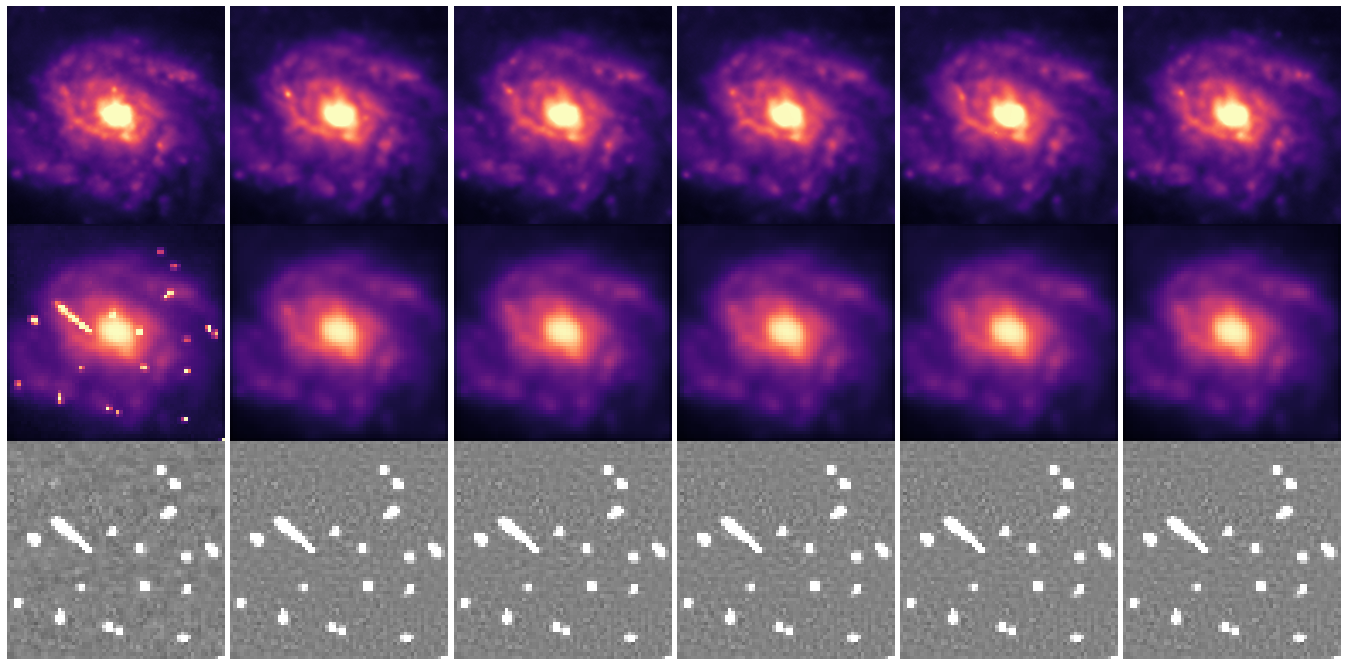

In [56]:
# fudge factor = 1000
fig, axs = plt.subplots(3, 6, figsize=(24, 12))
y_hat = forward_model(link_function(x_mean))

axs[0, 0].imshow(link_function(source).cpu().squeeze(), cmap="magma", vmin=0, vmax=1)
axs[0, 0].axis("off")
axs[1, 0].imshow(observation.cpu().squeeze(), cmap="magma", vmin=0, vmax=1)
axs[1, 0].axis("off")
axs[2, 0].imshow(noise_map.cpu().squeeze(),  cmap="gray", vmin=-0.04, vmax=0.08)
axs[2, 0].axis("off")
for j in range(5):
    axs[0, j+1].imshow(link_function(x_mean[j]).cpu().squeeze(), cmap="magma", vmin=0, vmax=1)
    axs[0, j+1].axis("off")
    axs[1, j+1].imshow(y_hat[j].cpu().squeeze(), cmap="magma", vmin=0, vmax=1)
    axs[1, j+1].axis("off")
    axs[2, j+1].imshow((observation - y_hat[j]).cpu().squeeze(), cmap="gray", vmin=-0.04, vmax=0.08)
    axs[2, j+1].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)

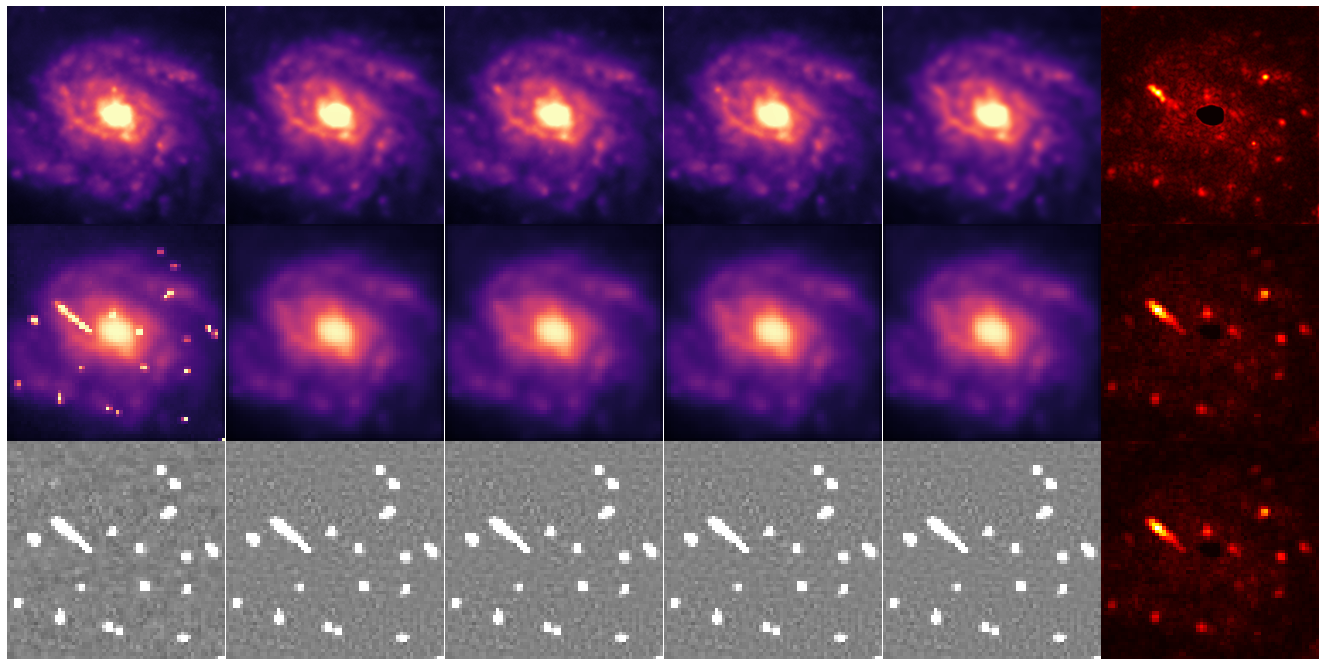

In [65]:
# statistics
# fudge factor = 1000
fig, axs = plt.subplots(3, 6, figsize=(24, 12))
y_hat = forward_model(link_function(x_mean))

axs[0, 0].imshow(link_function(source).cpu().squeeze(), cmap="magma", vmin=0, vmax=1)
axs[0, 0].axis("off")
axs[1, 0].imshow(observation.cpu().squeeze(), cmap="magma", vmin=0, vmax=1)
axs[1, 0].axis("off")
axs[2, 0].imshow(noise_map.cpu().squeeze(),  cmap="gray", vmin=-0.04, vmax=0.08)
axs[2, 0].axis("off")
for j in range(3):
    axs[0, j+1].imshow(link_function(x_mean[j]).cpu().squeeze(), cmap="magma", vmin=0, vmax=1)
    axs[0, j+1].axis("off")
    axs[1, j+1].imshow(y_hat[j].cpu().squeeze(), cmap="magma", vmin=0, vmax=1)
    axs[1, j+1].axis("off")
    axs[2, j+1].imshow((observation - y_hat[j]).cpu().squeeze(), cmap="gray", vmin=-0.04, vmax=0.08)
    axs[2, j+1].axis("off")
    
    axs[0, -2].imshow(link_function(x_mean.mean(dim=0)).cpu().squeeze(), cmap="magma", vmin=0, vmax=1)
    axs[0, -2].axis("off")
    axs[1, -2].imshow(y_hat.mean(dim=0).cpu().squeeze(), cmap="magma", vmin=0, vmax=1)
    axs[1, -2].axis("off")
    axs[2, -2].imshow((observation - y_hat).mean(dim=0).cpu().squeeze(), cmap="gray", vmin=-0.04, vmax=0.08)
    axs[2, -2].axis("off")
    
    axs[0, -1].imshow(link_function(x_mean.std(dim=0)).cpu().squeeze(), cmap="hot")
    axs[0, -1].axis("off")
    axs[1, -1].imshow(y_hat.std(dim=0).cpu().squeeze(), cmap="hot")
    axs[1, -1].axis("off")
    axs[2, -1].imshow((observation - y_hat).std(dim=0).cpu().squeeze(), cmap="hot")
    axs[2, -1].axis("off")
plt.subplots_adjust(hspace=0, wspace=-0.107)

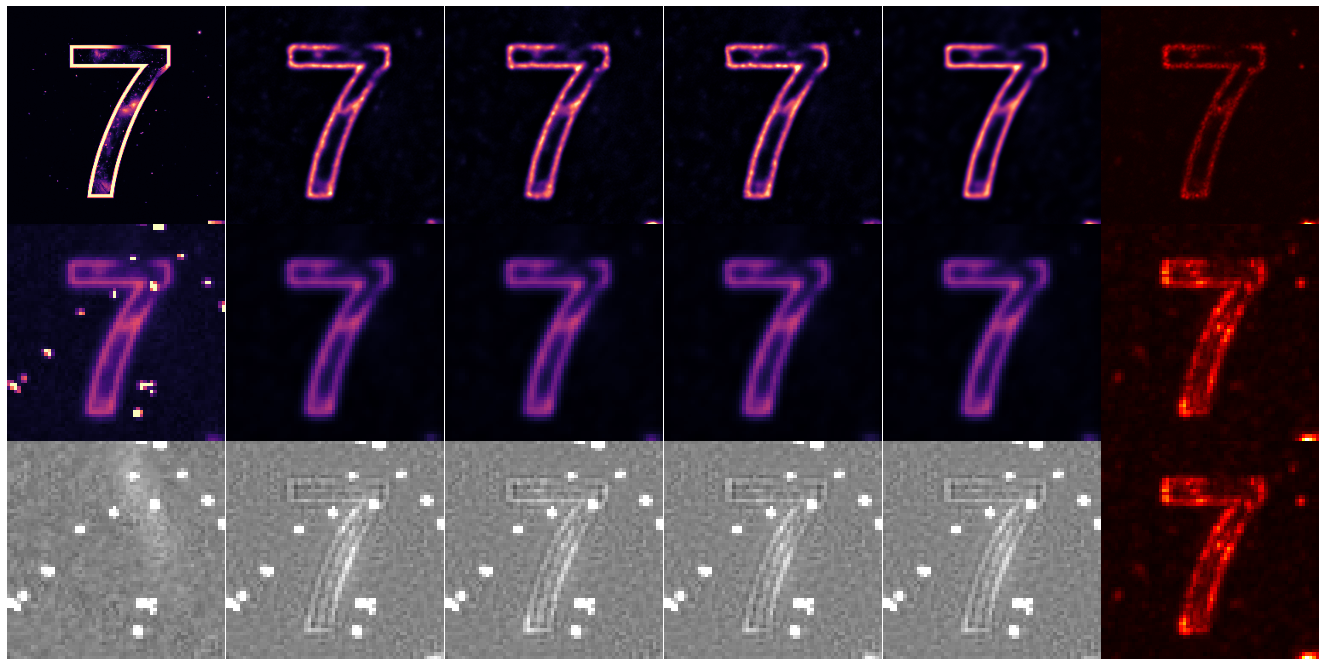

In [70]:
# statistics
# fudge factor = 1000
fig, axs = plt.subplots(3, 6, figsize=(24, 12))
y_hat = forward_model(link_function(x_mean))

axs[0, 0].imshow(link_function(source).cpu().squeeze(), cmap="magma", vmin=0, vmax=0.5)
axs[0, 0].axis("off")
axs[1, 0].imshow(observation.cpu().squeeze(), cmap="magma", vmin=0, vmax=0.5)
axs[1, 0].axis("off")
axs[2, 0].imshow(noise_map.cpu().squeeze(),  cmap="gray", vmin=-0.04, vmax=0.08)
axs[2, 0].axis("off")
for j in range(3):
    axs[0, j+1].imshow(link_function(x_mean[j]).cpu().squeeze(), cmap="magma", vmin=0, vmax=0.5)
    axs[0, j+1].axis("off")
    axs[1, j+1].imshow(y_hat[j].cpu().squeeze(), cmap="magma", vmin=0, vmax=0.5)
    axs[1, j+1].axis("off")
    axs[2, j+1].imshow((observation - y_hat[j]).cpu().squeeze(), cmap="gray", vmin=-0.04, vmax=0.08)
    axs[2, j+1].axis("off")
    
    axs[0, -2].imshow(link_function(x_mean.mean(dim=0)).cpu().squeeze(), cmap="magma", vmin=0, vmax=0.5)
    axs[0, -2].axis("off")
    axs[1, -2].imshow(y_hat.mean(dim=0).cpu().squeeze(), cmap="magma", vmin=0, vmax=0.5)
    axs[1, -2].axis("off")
    axs[2, -2].imshow((observation - y_hat).mean(dim=0).cpu().squeeze(), cmap="gray", vmin=-0.04, vmax=0.08)
    axs[2, -2].axis("off")
    
    axs[0, -1].imshow(link_function(x_mean.std(dim=0)).cpu().squeeze(), cmap="hot")
    axs[0, -1].axis("off")
    axs[1, -1].imshow(y_hat.std(dim=0).cpu().squeeze(), cmap="hot")
    axs[1, -1].axis("off")
    axs[2, -1].imshow((observation - y_hat).std(dim=0).cpu().squeeze(), cmap="hot")
    axs[2, -1].axis("off")
plt.subplots_adjust(hspace=0, wspace=-0.107)

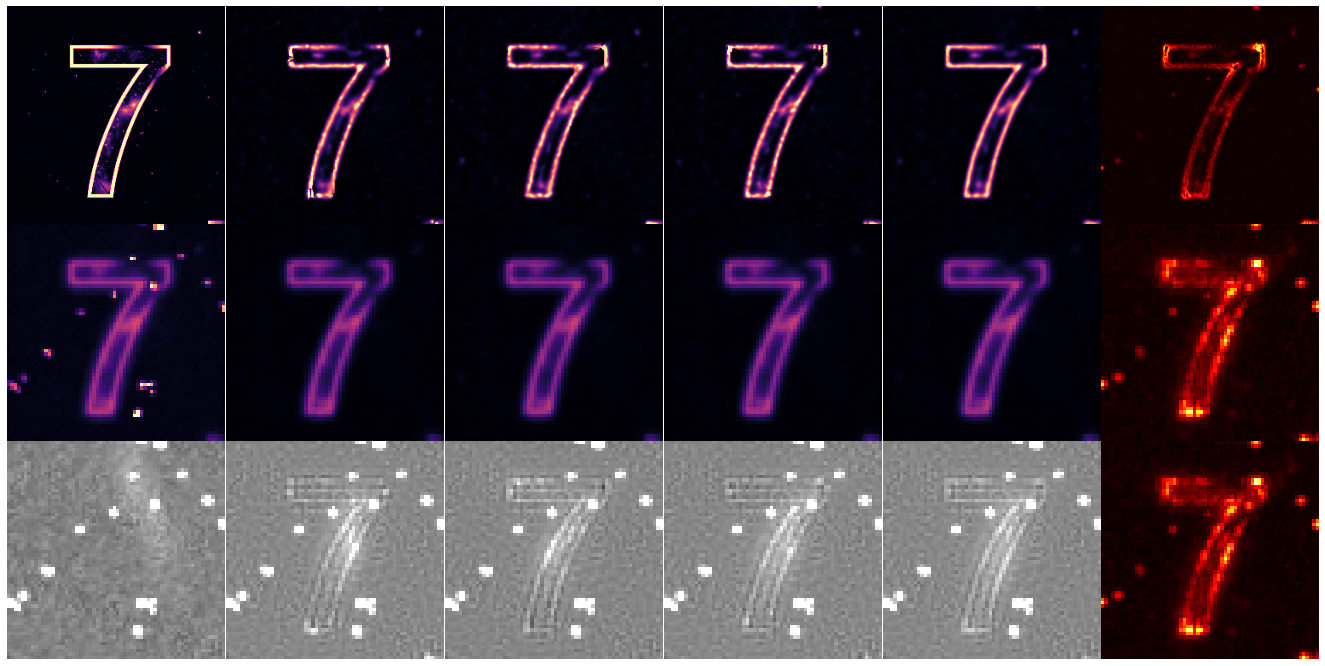

In [83]:
# statistics
# fudge factor = 2000
fig, axs = plt.subplots(3, 6, figsize=(24, 12))
y_hat = forward_model(link_function(x_mean))

axs[0, 0].imshow(link_function(source).cpu().squeeze(), cmap="magma", vmin=0, vmax=1)
axs[0, 0].axis("off")
axs[1, 0].imshow(observation.cpu().squeeze(), cmap="magma", vmin=0, vmax=1)
axs[1, 0].axis("off")
axs[2, 0].imshow(noise_map.cpu().squeeze(),  cmap="gray", vmin=-0.04, vmax=0.08)
axs[2, 0].axis("off")
for j in range(3):
    axs[0, j+1].imshow(link_function(x_mean[j]).cpu().squeeze(), cmap="magma", vmin=0, vmax=1)
    axs[0, j+1].axis("off")
    axs[1, j+1].imshow(y_hat[j].cpu().squeeze(), cmap="magma", vmin=0, vmax=1)
    axs[1, j+1].axis("off")
    axs[2, j+1].imshow((observation - y_hat[j]).cpu().squeeze(), cmap="gray", vmin=-0.04, vmax=0.08)
    axs[2, j+1].axis("off")
    
    axs[0, -2].imshow(link_function(x_mean.mean(dim=0)).cpu().squeeze(), cmap="magma", vmin=0, vmax=1)
    axs[0, -2].axis("off")
    axs[1, -2].imshow(y_hat.mean(dim=0).cpu().squeeze(), cmap="magma", vmin=0, vmax=1)
    axs[1, -2].axis("off")
    axs[2, -2].imshow((observation - y_hat).mean(dim=0).cpu().squeeze(), cmap="gray", vmin=-0.04, vmax=0.08)
    axs[2, -2].axis("off")
    
    axs[0, -1].imshow(link_function(x_mean.std(dim=0)).cpu().squeeze(), cmap="hot")
    axs[0, -1].axis("off")
    axs[1, -1].imshow(y_hat.std(dim=0).cpu().squeeze(), cmap="hot")
    axs[1, -1].axis("off")
    axs[2, -1].imshow((observation - y_hat).std(dim=0).cpu().squeeze(), cmap="hot")
    axs[2, -1].axis("off")
plt.subplots_adjust(hspace=0, wspace=-0.107)